# nanograd exploration

Walking through what I built — from scalar autograd to training CNNs on MNIST.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)

Matplotlib is building the font cache; this may take a moment.


## 1. Scalar autograd

The foundation — a `Value` class that tracks operations and computes gradients via the chain rule.

In [2]:
from engine import Value

# build a small expression: f(a, b) = (a * b + a) ** 2
a = Value(2.0)
b = Value(3.0)
c = a * b       # 6.0
d = c + a       # 8.0
f = d ** 2       # 64.0

f.backward()

print(f'f = {f.data}')
print(f'df/da = {a.grad}')  # d/da of (a*b + a)^2 = 2(a*b+a)(b+1) = 2*8*4 = 64
print(f'df/db = {b.grad}')  # d/db of (a*b + a)^2 = 2(a*b+a)(a) = 2*8*2 = 32

f = 64.0
df/da = 64.0
df/db = 32.0


## 2. Tensor autograd

Scaling up from scalars to numpy-backed tensors. The tricky part is handling broadcasting gradients correctly.

In [3]:
from nanograd import Tensor
import torch

# verify our gradients match pytorch on a non-trivial expression
# f(W, x, b) = relu(W @ x + b).mean()
W_np = np.random.randn(3, 4).astype(np.float32)
x_np = np.random.randn(4, 2).astype(np.float32)
b_np = np.random.randn(3, 1).astype(np.float32)

# nanograd
W = Tensor(W_np, requires_grad=True)
x = Tensor(x_np, requires_grad=True)
b = Tensor(b_np, requires_grad=True)
out = (W @ x + b).relu().mean()
out.backward()

# pytorch
Wt = torch.tensor(W_np, requires_grad=True)
xt = torch.tensor(x_np, requires_grad=True)
bt = torch.tensor(b_np, requires_grad=True)
out_t = (Wt @ xt + bt).relu().mean()
out_t.backward()

print('relu(W @ x + b).mean() gradient comparison:')
print(f'  W gradient match: {np.allclose(W.grad, Wt.grad.numpy(), atol=1e-6)}')
print(f'  x gradient match: {np.allclose(x.grad, xt.grad.numpy(), atol=1e-6)}')
print(f'  b gradient match: {np.allclose(b.grad, bt.grad.numpy(), atol=1e-6)}')
print(f'\nThis is basically a forward pass through a neural network layer — and our')
print(f'gradients are exact matches to PyTorch.')

relu(W @ x + b).mean() gradient comparison:
  W gradient match: True
  x gradient match: True
  b gradient match: True

This is basically a forward pass through a neural network layer — and our
gradients are exact matches to PyTorch.


## 3. Training an MLP on MNIST

Let's train a real neural network and plot the learning curves.

In [4]:
from nanograd.nn import Linear, ReLU, Sequential, CrossEntropyLoss, Dropout
from nanograd.optim import Adam
from nanograd.data import DataLoader, load_mnist

X_train, y_train, X_test, y_test = load_mnist()
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (60000, 784), Test: (10000, 784)


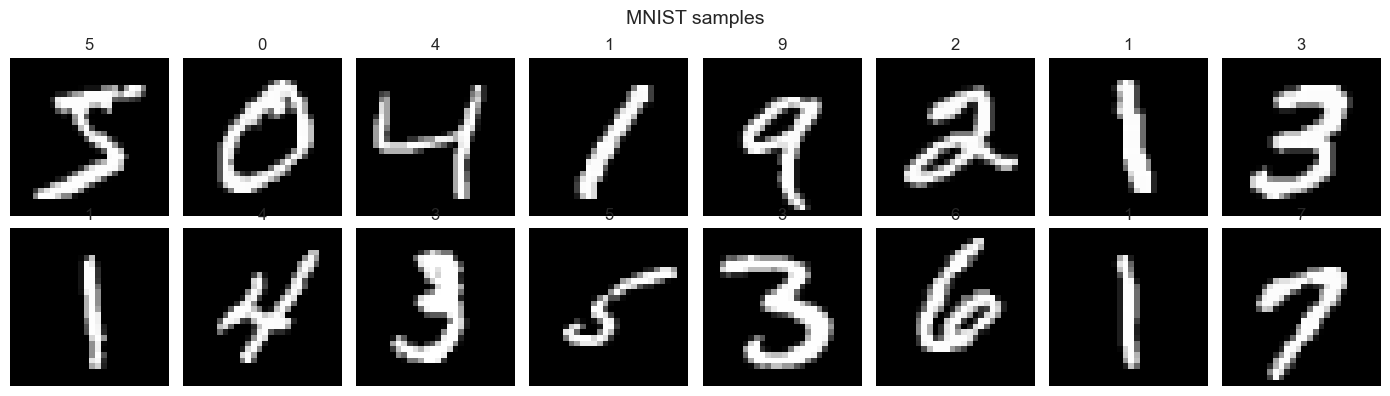

In [5]:
# visualize some samples
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'{y_train[i]}', fontsize=12)
    ax.axis('off')
plt.suptitle('MNIST samples', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# train MLP
model = Sequential(
    Linear(784, 128),
    ReLU(),
    Dropout(0.2),
    Linear(128, 64),
    ReLU(),
    Dropout(0.2),
    Linear(64, 10),
)

criterion = CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-3)

EPOCHS = 10
train_loader = DataLoader(X_train, y_train, batch_size=64)
test_loader = DataLoader(X_test, y_test, batch_size=256, shuffle=False)

history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(EPOCHS):
    model.set_training(True)
    total_loss, correct, total = 0, 0, 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.data.item() * len(batch_y)
        correct += (logits.data.argmax(axis=1) == batch_y).sum()
        total += len(batch_y)
    
    model.set_training(False)
    test_correct, test_total = 0, 0
    for batch_X, batch_y in test_loader:
        preds = model(batch_X).data.argmax(axis=1)
        test_correct += (preds == batch_y).sum()
        test_total += len(batch_y)
    
    history['train_loss'].append(total_loss / total)
    history['train_acc'].append(correct / total)
    history['test_acc'].append(test_correct / test_total)
    
    print(f'Epoch {epoch+1:2d}/{EPOCHS} | '
          f'loss: {history["train_loss"][-1]:.4f} | '
          f'train: {history["train_acc"][-1]:.4f} | '
          f'test: {history["test_acc"][-1]:.4f}')

Epoch  1/10 | loss: 0.3929 | train: 0.8817 | test: 0.9549


Epoch  2/10 | loss: 0.1848 | train: 0.9456 | test: 0.9673


Epoch  3/10 | loss: 0.1406 | train: 0.9573 | test: 0.9696


Epoch  4/10 | loss: 0.1142 | train: 0.9654 | test: 0.9710


Epoch  5/10 | loss: 0.0983 | train: 0.9701 | test: 0.9758


Epoch  6/10 | loss: 0.0888 | train: 0.9717 | test: 0.9747


Epoch  7/10 | loss: 0.0796 | train: 0.9754 | test: 0.9760


Epoch  8/10 | loss: 0.0723 | train: 0.9775 | test: 0.9776


Epoch  9/10 | loss: 0.0681 | train: 0.9784 | test: 0.9788


Epoch 10/10 | loss: 0.0650 | train: 0.9788 | test: 0.9796


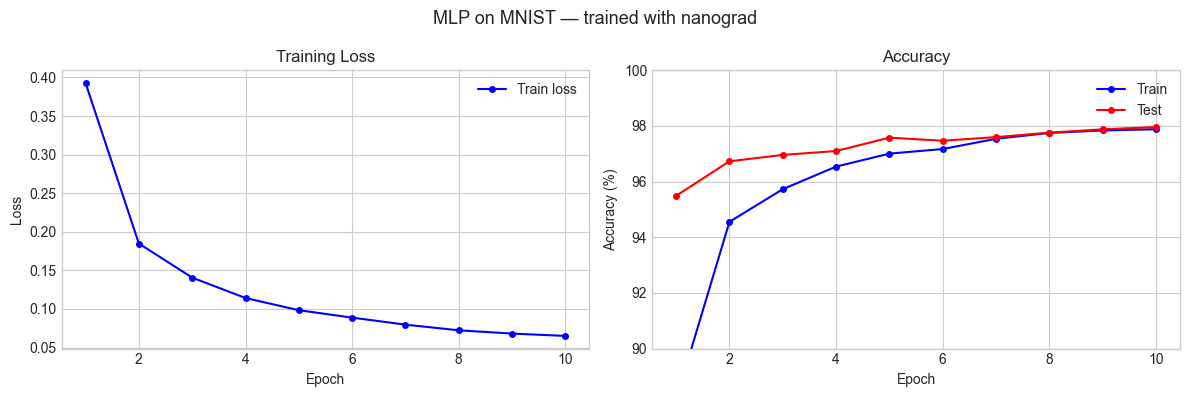

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, EPOCHS + 1)

ax1.plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Train loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()

ax2.plot(epochs, [a * 100 for a in history['train_acc']], 'b-o', markersize=4, label='Train')
ax2.plot(epochs, [a * 100 for a in history['test_acc']], 'r-o', markersize=4, label='Test')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy')
ax2.legend()
ax2.set_ylim(90, 100)

plt.suptitle('MLP on MNIST — trained with nanograd', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Visualizing predictions

Let's see what the model gets right and wrong.

In [8]:
# get predictions on test set
model.set_training(False)
all_preds = []
for batch_X, batch_y in test_loader:
    preds = model(batch_X).data.argmax(axis=1)
    all_preds.extend(preds)
all_preds = np.array(all_preds)

# find correct and incorrect predictions
correct_mask = all_preds == y_test
incorrect_idx = np.where(~correct_mask)[0]

print(f'Test accuracy: {correct_mask.mean() * 100:.2f}%')
print(f'Errors: {len(incorrect_idx)} / {len(y_test)}')

Test accuracy: 97.96%
Errors: 204 / 10000


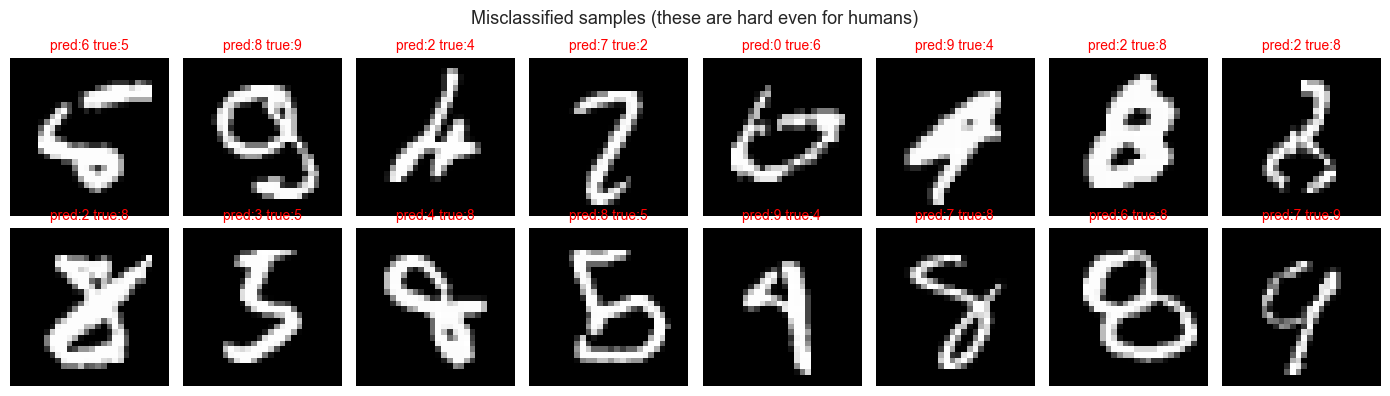

In [9]:
# show some mistakes — these are usually ambiguous even to humans
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    if i < len(incorrect_idx):
        idx = incorrect_idx[i]
        ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
        ax.set_title(f'pred:{all_preds[idx]} true:{y_test[idx]}', 
                     fontsize=10, color='red')
    ax.axis('off')
plt.suptitle('Misclassified samples (these are hard even for humans)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Numerical gradient verification

One of the most important things I built: verifying analytical gradients against numerical (finite difference) gradients. If these don't match, something is wrong in the backward pass.

In [10]:
from grad_check import check_gradient

# test a 2-layer network's gradients
W1 = Tensor(np.random.randn(5, 3).astype(np.float32), requires_grad=True)
b1 = Tensor(np.random.randn(5, 1).astype(np.float32), requires_grad=True)
W2 = Tensor(np.random.randn(2, 5).astype(np.float32), requires_grad=True)
b2 = Tensor(np.random.randn(2, 1).astype(np.float32), requires_grad=True)
x_in = Tensor(np.random.randn(3, 4).astype(np.float32), requires_grad=True)

def f():
    for t in [W1, b1, W2, b2, x_in]:
        t.grad = np.zeros_like(t.data)
    h = (W1 @ x_in + b1).relu()
    return (W2 @ h + b2).mean()

print('Checking gradients of W2 @ relu(W1 @ x + b1) + b2:')
assert check_gradient(f, [W1, b1, W2, b2, x_in])
print('\nAll analytical gradients match numerical gradients!')

Checking gradients of W2 @ relu(W1 @ x + b1) + b2:
OK tensor 0 (shape (5, 3)): max diff = 1.23e-03
OK tensor 1 (shape (5, 1)): max diff = 7.43e-05
OK tensor 2 (shape (2, 5)): max diff = 2.30e-04
OK tensor 3 (shape (2, 1)): max diff = 2.32e-04
OK tensor 4 (shape (3, 4)): max diff = 3.65e-04

All analytical gradients match numerical gradients!


## 6. Conv2d verification

The hardest part to implement — convolutions using the im2col trick. Let's verify it matches PyTorch exactly.

In [11]:
from nanograd.nn import Conv2d
import torch.nn as tnn

# build identical conv layers
conv_ng = Conv2d(3, 8, kernel_size=3, padding=1)
conv_pt = tnn.Conv2d(3, 8, kernel_size=3, padding=1)
conv_pt.weight.data = torch.tensor(conv_ng.weight.data)
conv_pt.bias.data = torch.tensor(conv_ng.bias.data)

# random input image batch
x_np = np.random.randn(4, 3, 8, 8).astype(np.float32)

# forward
x_ng = Tensor(x_np, requires_grad=True)
x_pt = torch.tensor(x_np, requires_grad=True)

out_ng = conv_ng(x_ng)
out_pt = conv_pt(x_pt)

# backward
out_ng.sum().backward()
out_pt.sum().backward()

print('Conv2d(3, 8, kernel_size=3, padding=1) on (4, 3, 8, 8) input:')
print(f'  Forward match:      {np.allclose(out_ng.data, out_pt.detach().numpy(), atol=1e-5)}')
print(f'  Input grad match:   {np.allclose(x_ng.grad, x_pt.grad.numpy(), atol=1e-5)}')
print(f'  Weight grad match:  {np.allclose(conv_ng.weight.grad, conv_pt.weight.grad.numpy(), atol=1e-5)}')
print(f'  Bias grad match:    {np.allclose(conv_ng.bias.grad, conv_pt.bias.grad.numpy(), atol=1e-5)}')

Conv2d(3, 8, kernel_size=3, padding=1) on (4, 3, 8, 8) input:
  Forward match:      True
  Input grad match:   True
  Weight grad match:  True
  Bias grad match:    True


---

Everything is built from scratch with just numpy. No autograd framework under the hood — every gradient computation is explicitly implemented. The full source is in the `nanograd/` directory.